In [1]:
import os
import warnings
warnings.simplefilter("ignore")

import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import pairwise_distances, balanced_accuracy_score
from sklearn.metrics import confusion_matrix

from lib.data.utils import Color
from lib.data import (
    ColoredMNISTDataset,
    ColoredMNISTDatasetAblated,
    get_ColoredMNISTDataset_dataloader
)
from lib.models import (
    CVAE, CVAEFilm,
    AEModelConfig,
    TripleClassifier
)
from lib.analysis import tg_mds
from lib.plotting import fig_to_rgba
from lib import filepaths

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Training

In [ ]:
color_codes = [Color.RED, Color.GREEN, Color.CYAN, Color.YELLOW, Color.MAGENTA]

color_ids = np.arange(len(color_codes))
digit_ids = np.arange(10)

missing_pairs = np.array(np.meshgrid(digit_ids, color_ids)).reshape(2,-1).T

###

def train_cvae(
    cvae,
    train_dataloader,
    test_dataloader,
    lr: float = 0.0015,
    epochs: int = 2
):
    cvae.to(device)

    optimizer = torch.optim.AdamW(
        cvae.parameters(),
        lr=lr
    )

    def train(epoch):
        cvae.train()

        loss = []
        rec_loss = []
        kld_loss = []
        with tqdm(train_dataloader) as t_epoch:
            for batch in t_epoch:
                t_epoch.set_description(f"Train | Epoch {epoch+1}")
                
                batch.to(device)
                
                output = cvae(
                    pixel_values=batch.pixel_values, 
                    label_ids=batch.label_ids, 
                    feature_ids=batch.feature_ids
                )

                optimizer.zero_grad()
                J = output.loss
                J.backward()
                optimizer.step()

                loss.append(float(J))
                rec_loss.append(float(output.rec_loss))
                kld_loss.append(float(output.kld_loss))

                t_epoch.set_postfix(dict(
                    loss=np.mean(loss),
                    rec_loss=np.mean(rec_loss),
                    kld_loss=np.mean(kld_loss)
                ))

    @torch.no_grad()
    def test(epoch):
        cvae.eval()

        loss = []
        rec_loss = []
        kld_loss = []
        with tqdm(test_dataloader) as t_epoch:
            for batch in t_epoch:
                t_epoch.set_description(f"Test | Epoch {epoch+1}")
                
                batch.to(device)
                
                output = cvae(
                    pixel_values=batch.pixel_values, 
                    label_ids=batch.label_ids, 
                    feature_ids=batch.feature_ids
                )

                loss.append(float(output.loss))
                rec_loss.append(float(output.rec_loss))
                kld_loss.append(float(output.kld_loss))

                t_epoch.set_postfix(dict(
                    loss=np.mean(loss),
                    rec_loss=np.mean(rec_loss),
                    kld_loss=np.mean(kld_loss)
                ))

    for i in range(epochs):
        train(i)
        test(i)

###

saveroot = Path("")

batch_size = 64

#--- Model ---#
ae_config = AEModelConfig(
    latent_dim=16,
    hidden_dim_base=16,
    m=3,
    kld_beta=0.5
)

kwargs = dict(
    n_labels=10,
    n_features=len(color_codes),
    image_size=32,
    n_cond_channels=4
)
#--- ---#


for loo_pair in missing_pairs:

    train_dataset_ablated = ColoredMNISTDatasetAblated(
        missing_pairs=[tuple(loo_pair)],
        color_codes=color_codes,
        train=True
    )

    test_dataset_ablated = ColoredMNISTDatasetAblated(
        missing_pairs=[tuple(loo_pair)],
        color_codes=color_codes,
        train=False
    )

    train_dataloader_ablated = get_ColoredMNISTDataset_dataloader(
        batch_size=batch_size,
        dataset=train_dataset_ablated,
        shuffle=True,
        drop_last=True
    )

    test_dataloader_ablated = get_ColoredMNISTDataset_dataloader(
        batch_size=batch_size,
        dataset=test_dataset_ablated,
        shuffle=False,
        drop_last=True
    )

    #--- EXPERIMENT ---#

    cvae = CVAEFilm(
        config=ae_config,
        **kwargs
    )

    train_cvae(
        cvae,
        train_dataloader=train_dataloader_ablated,
        test_dataloader=test_dataloader_ablated,
        lr=0.0025,
        epochs=4
    )

    #--- SAVE ---#

    ckpt = dict(
        state_dit=cvae.state_dict(),
        config=cvae.config,
        kwargs=kwargs
    )

    torch.save(ckpt, saveroot/"")

# Analysis

In [12]:
root = Path("resources/loo/datasets")

df = []
for filename in os.listdir(root):
    data = np.load(root/filename, allow_pickle=True).item()
    table = data["table"]
    df.append(table)

df = pd.concat(df)

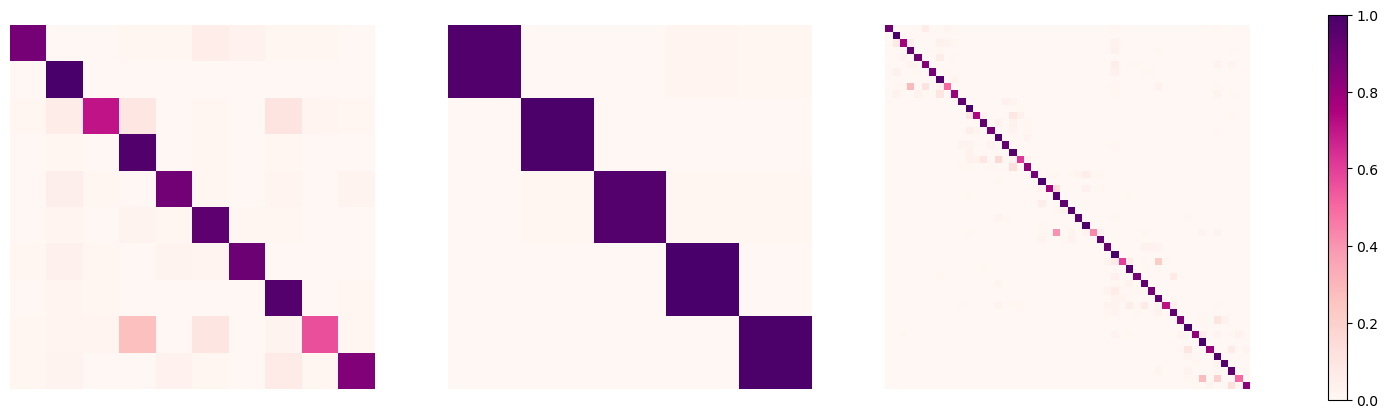

In [9]:
fig, axes = plt.subplots(1,3, figsize=(20,5))
cmap = "RdPu"

c = confusion_matrix(df.true_digit.values, df.pred_digit.values, normalize="true")
sns.heatmap(c, square=True, annot=False, cmap=cmap, vmin=0, vmax=1, ax=axes[0], cbar=False)

c = confusion_matrix(df.true_color.values, df.pred_color.values, normalize="true")
sns.heatmap(c, square=True, annot=False, cmap=cmap, vmin=0, vmax=1, ax=axes[1], cbar=False)

c = confusion_matrix(df.true_pair.values, df.pred_pair.values, normalize="true")
sns.heatmap(c, square=True, annot=False, cmap=cmap, vmin=0, vmax=1, ax=axes[2], cbar=False)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(ax.collections[0], ax=axes, orientation="vertical")

fig.savefig("visuals/loo-confusion_mat.pdf")